# Task 1 — ResNet-152


## Setup


In [34]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd

from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights


SEED = 42
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 0.001

RESULTS_DIR = Path("task1/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Dataset and DataLoaders


In [6]:
weights = ResNet152_Weights.DEFAULT
transform = weights.transforms()

full_train_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/sohauvv/cifar10-local",
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/sohauvv/cifar10-local",
    train=False,
    download=False,
    transform=transform,
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print()

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train images: 45000
Validation images: 5000
Test images: 10000

Train batches: 1407
Validation batches: 157
Test batches: 313


## Training and Evaluation Functions

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 1.1 Transfer Learning Baseline

In [8]:
baseline_model = resnet152(weights=weights)

baseline_model.fc = nn.Linear(
    baseline_model.fc.in_features,
    10,
)


# Freeze the pretrained backbone
for param in baseline_model.parameters():
    param.requires_grad = False


# Train only the new classification head
for param in baseline_model.fc.parameters():
    param.requires_grad = True


baseline_model = baseline_model.to(device)


trainable_params = sum(
    param.numel()
    for param in baseline_model.parameters()
    if param.requires_grad
)

total_params = sum(
    param.numel()
    for param in baseline_model.parameters()
)


print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print("Classifier:", baseline_model.fc)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 196MB/s] 


Trainable parameters: 20,490
Total parameters: 58,164,298
Classifier: Linear(in_features=2048, out_features=10, bias=True)


### Training

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    baseline_model.fc.parameters(),
    lr=LEARNING_RATE,
)


baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        baseline_model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate(
        baseline_model,
        val_loader,
        criterion,
        device,
    )

    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.7041 | Train Acc: 0.7757 | Val Loss: 0.5211 | Val Acc: 0.8270
Epoch 2/3 | Train Loss: 0.5192 | Train Acc: 0.8242 | Val Loss: 0.5049 | Val Acc: 0.8320
Epoch 3/3 | Train Loss: 0.4808 | Train Acc: 0.8354 | Val Loss: 0.4712 | Val Acc: 0.8432


### Test Evaluation

In [20]:
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model,
    test_loader,
    criterion,
    device,
)


print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")

Test Loss: 0.4778
Test Accuracy: 0.8390


### Results

In [21]:
# Save epoch-by-epoch history

history_path = RESULTS_DIR / "baseline_history.csv"

with open(history_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
    ])

    for epoch in range(EPOCHS):
        writer.writerow([
            epoch + 1,
            baseline_history["train_loss"][epoch],
            baseline_history["train_acc"][epoch],
            baseline_history["val_loss"][epoch],
            baseline_history["val_acc"][epoch],
        ])


# Save final metrics

summary_path = RESULTS_DIR / "baseline_summary.csv"

with open(summary_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "final_train_loss",
        "final_train_acc",
        "final_val_loss",
        "final_val_acc",
        "test_loss",
        "test_acc",
    ])

    writer.writerow([
        baseline_history["train_loss"][-1],
        baseline_history["train_acc"][-1],
        baseline_history["val_loss"][-1],
        baseline_history["val_acc"][-1],
        baseline_test_loss,
        baseline_test_acc,
    ])


print("History saved to:", history_path)
print("Summary saved to:", summary_path)

History saved to: task1/results/baseline_history.csv
Summary saved to: task1/results/baseline_summary.csv


### Training Curves

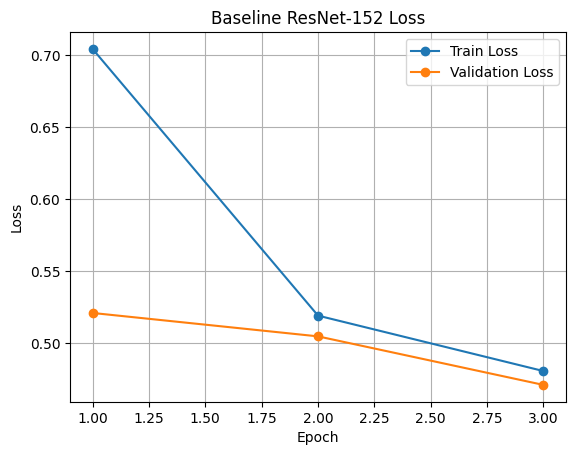

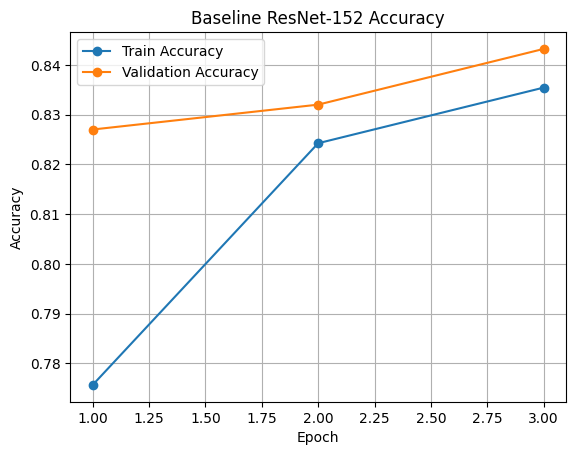

Loss plot saved to: task1/results/baseline_loss.png
Accuracy plot saved to: task1/results/baseline_accuracy.png


In [22]:
epochs_range = range(1, EPOCHS + 1)


# Loss

plt.figure()

plt.plot(
    epochs_range,
    baseline_history["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    epochs_range,
    baseline_history["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline ResNet-152 Loss")
plt.legend()
plt.grid()

loss_plot_path = RESULTS_DIR / "baseline_loss.png"

plt.savefig(
    loss_plot_path,
    bbox_inches="tight",
)

plt.show()


# Accuracy

plt.figure()

plt.plot(
    epochs_range,
    baseline_history["train_acc"],
    marker="o",
    label="Train Accuracy",
)

plt.plot(
    epochs_range,
    baseline_history["val_acc"],
    marker="o",
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ResNet-152 Accuracy")
plt.legend()
plt.grid()

accuracy_plot_path = RESULTS_DIR / "baseline_accuracy.png"

plt.savefig(
    accuracy_plot_path,
    bbox_inches="tight",
)

plt.show()


print("Loss plot saved to:", loss_plot_path)
print("Accuracy plot saved to:", accuracy_plot_path)

## 1.2 Residual Connections in Practice

### Modified Residual Blocks


In [23]:
import types


def forward_without_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # Residual connection removed
    out = self.relu(out)

    return out

### Model Setup

In [24]:
no_skip_model = resnet152(weights=weights)

no_skip_model.fc = nn.Linear(
    no_skip_model.fc.in_features,
    10,
)


# Select one residual block from each stage
blocks_without_skip = [
    no_skip_model.layer1[1],
    no_skip_model.layer2[1],
    no_skip_model.layer3[1],
    no_skip_model.layer4[1],
]


# Replace their forward methods
for block in blocks_without_skip:
    block.forward = types.MethodType(
        forward_without_skip,
        block,
    )


# Freeze pretrained backbone
for param in no_skip_model.parameters():
    param.requires_grad = False


# Train only classifier
for param in no_skip_model.fc.parameters():
    param.requires_grad = True


no_skip_model = no_skip_model.to(device)


print("Skip connections disabled in:")
print("layer1[1]")
print("layer2[1]")
print("layer3[1]")
print("layer4[1]")

Skip connections disabled in:
layer1[1]
layer2[1]
layer3[1]
layer4[1]


### Training

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    no_skip_model.fc.parameters(),
    lr=LEARNING_RATE,
)


no_skip_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        no_skip_model,
        train_loader,
        criterion,
        optimizer,
        device,
    )

    val_loss, val_acc = evaluate(
        no_skip_model,
        val_loader,
        criterion,
        device,
    )

    no_skip_history["train_loss"].append(train_loss)
    no_skip_history["train_acc"].append(train_acc)
    no_skip_history["val_loss"].append(val_loss)
    no_skip_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 2.3015 | Train Acc: 0.1063 | Val Loss: 2.5446 | Val Acc: 0.1138
Epoch 2/3 | Train Loss: 2.2989 | Train Acc: 0.1156 | Val Loss: 2.4674 | Val Acc: 0.1232
Epoch 3/3 | Train Loss: 2.2975 | Train Acc: 0.1178 | Val Loss: 2.4069 | Val Acc: 0.1154


### Test Evaluation

In [26]:
no_skip_test_loss, no_skip_test_acc = evaluate(
    no_skip_model,
    test_loader,
    criterion,
    device,
)

print(f"Test Loss: {no_skip_test_loss:.4f}")
print(f"Test Accuracy: {no_skip_test_acc:.4f}")

Test Loss: 2.4321
Test Accuracy: 0.1207


### Results

In [28]:
# Save no-skip history
no_skip_history_path = RESULTS_DIR / "no_skip_history.csv"

with open(no_skip_history_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
    ])

    for epoch in range(EPOCHS):
        writer.writerow([
            epoch + 1,
            no_skip_history["train_loss"][epoch],
            no_skip_history["train_acc"][epoch],
            no_skip_history["val_loss"][epoch],
            no_skip_history["val_acc"][epoch],
        ])


# Save no-skip summary
no_skip_summary_path = RESULTS_DIR / "no_skip_summary.csv"

with open(no_skip_summary_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "final_train_loss",
        "final_train_acc",
        "final_val_loss",
        "final_val_acc",
        "test_loss",
        "test_acc",
    ])

    writer.writerow([
        no_skip_history["train_loss"][-1],
        no_skip_history["train_acc"][-1],
        no_skip_history["val_loss"][-1],
        no_skip_history["val_acc"][-1],
        no_skip_test_loss,
        no_skip_test_acc,
    ])


print("No-skip history saved to:", no_skip_history_path)
print("No-skip summary saved to:", no_skip_summary_path)

No-skip history saved to: task1/results/no_skip_history.csv
No-skip summary saved to: task1/results/no_skip_summary.csv


### Baseline Comparison

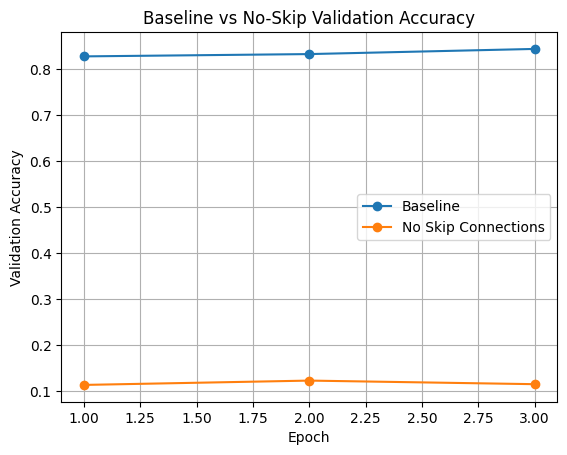

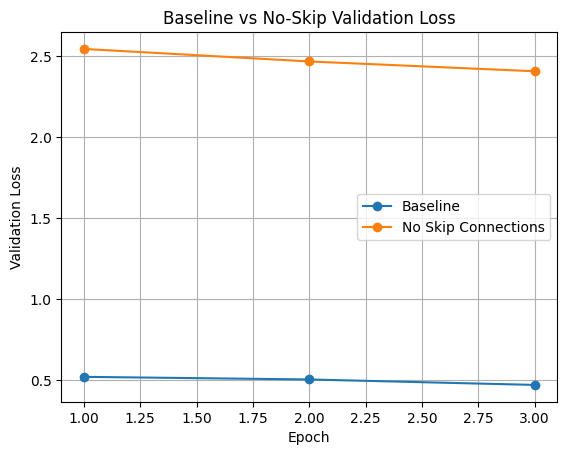

Comparison accuracy plot saved to: task1/results/baseline_vs_no_skip_accuracy.png
Comparison loss plot saved to: task1/results/baseline_vs_no_skip_loss.png


In [29]:
epochs_range = range(1, EPOCHS + 1)


# Validation accuracy comparison
plt.figure()

plt.plot(
    epochs_range,
    baseline_history["val_acc"],
    marker="o",
    label="Baseline",
)

plt.plot(
    epochs_range,
    no_skip_history["val_acc"],
    marker="o",
    label="No Skip Connections",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs No-Skip Validation Accuracy")
plt.legend()
plt.grid()

comparison_acc_path = RESULTS_DIR / "baseline_vs_no_skip_accuracy.png"

plt.savefig(
    comparison_acc_path,
    bbox_inches="tight",
)

plt.show()


# Validation loss comparison
plt.figure()

plt.plot(
    epochs_range,
    baseline_history["val_loss"],
    marker="o",
    label="Baseline",
)

plt.plot(
    epochs_range,
    no_skip_history["val_loss"],
    marker="o",
    label="No Skip Connections",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs No-Skip Validation Loss")
plt.legend()
plt.grid()

comparison_loss_path = RESULTS_DIR / "baseline_vs_no_skip_loss.png"

plt.savefig(
    comparison_loss_path,
    bbox_inches="tight",
)

plt.show()


print("Comparison accuracy plot saved to:", comparison_acc_path)
print("Comparison loss plot saved to:", comparison_loss_path)

## 1.3 Feature Hierarchies and Representations

### Feature Extraction

In [31]:
from sklearn.manifold import TSNE


feature_model = baseline_model
feature_model.eval()

features = {}


def get_activation(name):
    def hook(model, input, output):
        features[name] = output.detach().cpu()

    return hook


hooks = [
    feature_model.layer1.register_forward_hook(
        get_activation("early")
    ),
    feature_model.layer3.register_forward_hook(
        get_activation("middle")
    ),
    feature_model.layer4.register_forward_hook(
        get_activation("late")
    ),
]


MAX_SAMPLES = 1000

early_features = []
middle_features = []
late_features = []
feature_labels = []

samples_collected = 0


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        _ = feature_model(images)

        batch_size = images.size(0)
        remaining = MAX_SAMPLES - samples_collected
        take = min(batch_size, remaining)

        early_batch = features["early"][:take].mean(dim=(2, 3))
        middle_batch = features["middle"][:take].mean(dim=(2, 3))
        late_batch = features["late"][:take].mean(dim=(2, 3))

        early_features.append(early_batch)
        middle_features.append(middle_batch)
        late_features.append(late_batch)

        feature_labels.append(labels[:take])

        samples_collected += take

        if samples_collected >= MAX_SAMPLES:
            break


early_features = torch.cat(early_features).numpy()
middle_features = torch.cat(middle_features).numpy()
late_features = torch.cat(late_features).numpy()
feature_labels = torch.cat(feature_labels).numpy()


for hook in hooks:
    hook.remove()


print("Samples collected:", len(feature_labels))
print("Early features:", early_features.shape)
print("Middle features:", middle_features.shape)
print("Late features:", late_features.shape)

Samples collected: 1000
Early features: (1000, 256)
Middle features: (1000, 1024)
Late features: (1000, 2048)


### t-SNE Dimensionality Reduction

In [32]:
def run_tsne(feature_matrix):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=SEED,
        init="pca",
        learning_rate="auto",
    )

    return tsne.fit_transform(feature_matrix)


print("Running t-SNE on early-layer features...")
early_tsne = run_tsne(early_features)

print("Running t-SNE on middle-layer features...")
middle_tsne = run_tsne(middle_features)

print("Running t-SNE on late-layer features...")
late_tsne = run_tsne(late_features)

print("t-SNE complete.")

Running t-SNE on early-layer features...
Running t-SNE on middle-layer features...
Running t-SNE on late-layer features...
t-SNE complete.


### Feature Visualizations

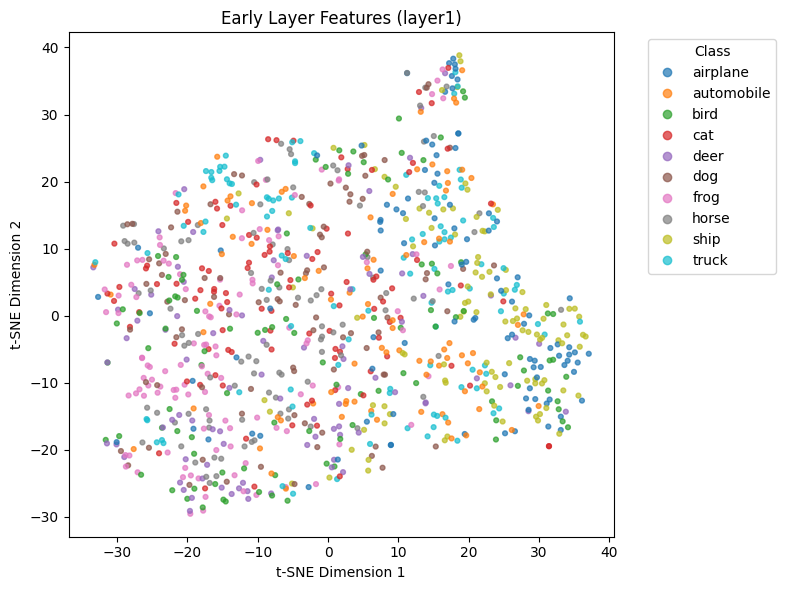

Saved to: task1/results/tsne_early_layer.png


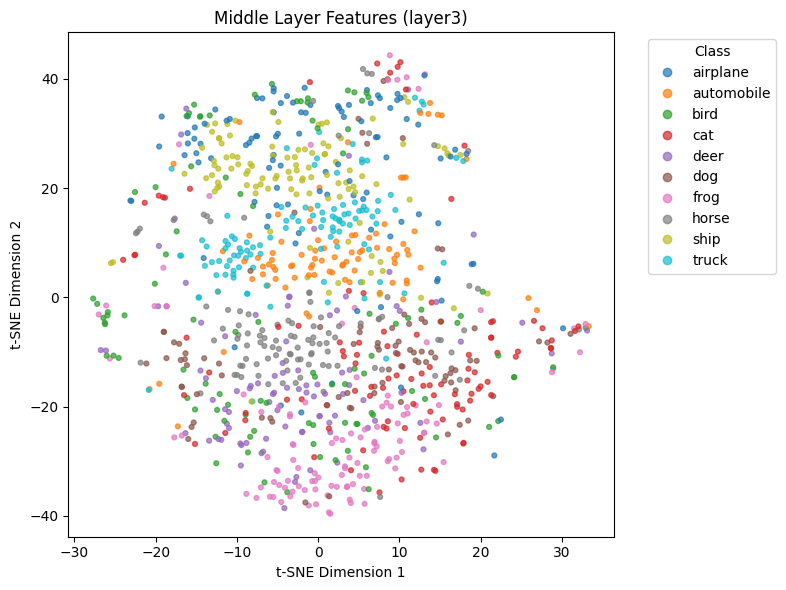

Saved to: task1/results/tsne_middle_layer.png


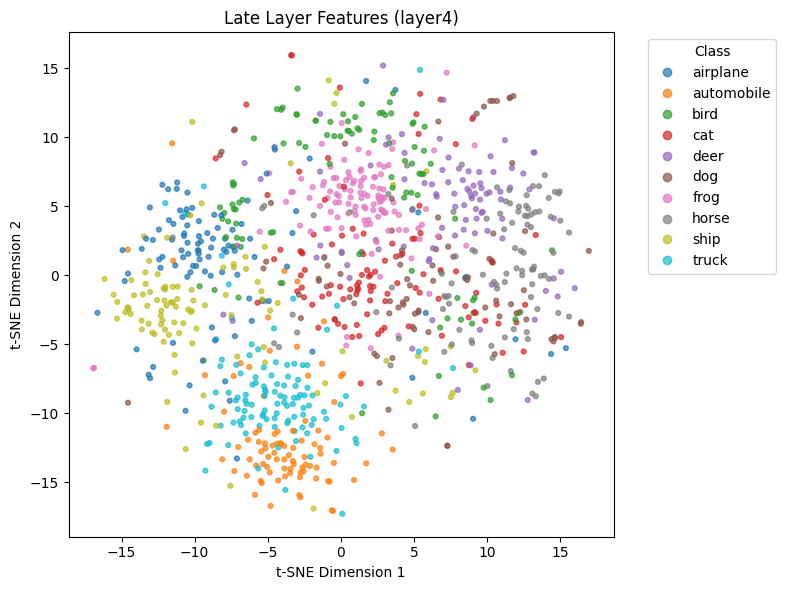

Saved to: task1/results/tsne_late_layer.png


In [33]:
class_names = test_dataset.classes


def plot_tsne(embedding, labels, title, save_name):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=12,
        alpha=0.7,
    )

    handles, _ = scatter.legend_elements()

    plt.legend(
        handles,
        class_names,
        title="Class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.title(title)

    plt.tight_layout()

    save_path = RESULTS_DIR / save_name

    plt.savefig(
        save_path,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved to:", save_path)


plot_tsne(
    early_tsne,
    feature_labels,
    "Early Layer Features (layer1)",
    "tsne_early_layer.png",
)

plot_tsne(
    middle_tsne,
    feature_labels,
    "Middle Layer Features (layer3)",
    "tsne_middle_layer.png",
)

plot_tsne(
    late_tsne,
    feature_labels,
    "Late Layer Features (layer4)",
    "tsne_late_layer.png",
)

## 1.4 Transfer Learning and Generalization

### Model Setup

In [3]:
def create_finetune_model(pretrained, mode):
    if pretrained:
        model = resnet152(weights=ResNet152_Weights.DEFAULT)
    else:
        model = resnet152(weights=None)

    model.fc = nn.Linear(model.fc.in_features, 10)

    if mode == "final_block":
        for param in model.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        for param in model.fc.parameters():
            param.requires_grad = True

    elif mode == "full":
        for param in model.parameters():
            param.requires_grad = True

    return model.to(device)

### Fine-Tuning Function

In [3]:
def run_finetuning_experiment(
    name,
    pretrained,
    mode,
    epochs=3,
):
    model = create_finetune_model(
        pretrained=pretrained,
        mode=mode,
    )

    optimizer = torch.optim.Adam(
        filter(
            lambda param: param.requires_grad,
            model.parameters(),
        ),
        lr=1e-4,
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    print(f"\n{name}")

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

    return {
        "name": name,
        "history": history,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }

### Pretrained — Final Block Fine-Tuning

In [14]:
pretrained_final = run_finetuning_experiment(
    name="Pretrained - Final Block",
    pretrained=True,
    mode="final_block",
    epochs=3,
)


Pretrained - Final Block
Epoch 1/3 | Train Loss: 0.5181 | Train Acc: 0.8330 | Val Loss: 0.2972 | Val Acc: 0.8978
Epoch 2/3 | Train Loss: 0.2367 | Train Acc: 0.9200 | Val Loss: 0.2931 | Val Acc: 0.9020
Epoch 3/3 | Train Loss: 0.1331 | Train Acc: 0.9554 | Val Loss: 0.2903 | Val Acc: 0.9076
Test Loss: 0.2925 | Test Acc: 0.9100


### Pretrained — Full Backbone Fine-Tuning

In [9]:
pretrained_full = run_finetuning_experiment(
    name="Pretrained - Full Backbone",
    pretrained=True,
    mode="full",
    epochs=3,
)


Pretrained - Full Backbone
Epoch 1/3 | Train Loss: 0.2568 | Train Acc: 0.9189 | Val Loss: 0.1169 | Val Acc: 0.9590
Epoch 2/3 | Train Loss: 0.0749 | Train Acc: 0.9756 | Val Loss: 0.1051 | Val Acc: 0.9646
Epoch 3/3 | Train Loss: 0.0550 | Train Acc: 0.9818 | Val Loss: 0.1228 | Val Acc: 0.9616
Test Loss: 0.1175 | Test Acc: 0.9619


### Random Initialization — Final Block Fine-Tuning

In [10]:
random_final = run_finetuning_experiment(
    name="Random - Final Block",
    pretrained=False,
    mode="final_block",
    epochs=3,
)


Random - Final Block
Epoch 1/3 | Train Loss: 2.0622 | Train Acc: 0.2346 | Val Loss: 1.9785 | Val Acc: 0.2960
Epoch 2/3 | Train Loss: 1.8602 | Train Acc: 0.3198 | Val Loss: 1.9147 | Val Acc: 0.3332
Epoch 3/3 | Train Loss: 1.7809 | Train Acc: 0.3539 | Val Loss: 1.7845 | Val Acc: 0.3592
Test Loss: 1.7665 | Test Acc: 0.3683


### Random Initialization — Full Backbone Fine-Tuning

In [11]:
random_full = run_finetuning_experiment(
    name="Random - Full Backbone",
    pretrained=False,
    mode="full",
    epochs=3,
)


Random - Full Backbone
Epoch 1/3 | Train Loss: 1.8195 | Train Acc: 0.3244 | Val Loss: 1.6761 | Val Acc: 0.4176
Epoch 2/3 | Train Loss: 1.4558 | Train Acc: 0.4690 | Val Loss: 1.4554 | Val Acc: 0.4874
Epoch 3/3 | Train Loss: 1.2633 | Train Acc: 0.5464 | Val Loss: 1.1216 | Val Acc: 0.5988
Test Loss: 1.1341 | Test Acc: 0.6046


### Results

In [16]:
transfer_results = [
    {
        "model": "Pretrained - Final Block",
        "test_loss": pretrained_final["test_loss"],
        "test_acc": pretrained_final["test_acc"],
    },
    {
        "model": "Pretrained - Full Backbone",
        "test_loss": pretrained_full["test_loss"],
        "test_acc": pretrained_full["test_acc"],
    },
    {
        "model": "Random - Final Block",
        "test_loss": random_final["test_loss"],
        "test_acc": random_final["test_acc"],
    },
    {
        "model": "Random - Full Backbone",
        "test_loss": random_full["test_loss"],
        "test_acc": random_full["test_acc"],
    },
]


transfer_results_df = pd.DataFrame(transfer_results)

transfer_results_path = RESULTS_DIR / "transfer_learning_results.csv"

transfer_results_df.to_csv(
    transfer_results_path,
    index=False,
)


print(transfer_results_df)
print("\nSaved to:", transfer_results_path)

                        model  test_loss  test_acc
0    Pretrained - Final Block   0.292488    0.9100
1  Pretrained - Full Backbone   0.117500    0.9619
2        Random - Final Block   1.766455    0.3683
3      Random - Full Backbone   1.134115    0.6046

Saved to: task1/results/transfer_learning_results.csv


### Test Accuracy Comparison

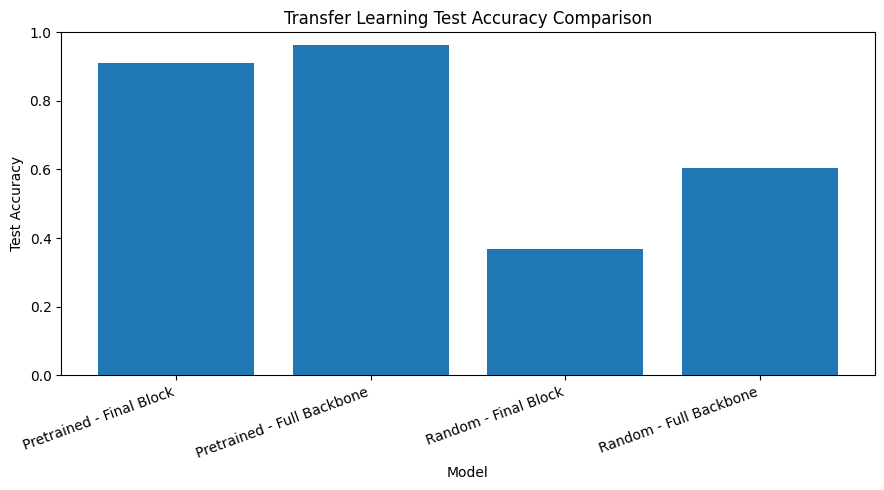

Saved to: task1/results/transfer_learning_accuracy.png


In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    transfer_results_df["model"],
    transfer_results_df["test_acc"],
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Transfer Learning Test Accuracy Comparison")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

transfer_plot_path = RESULTS_DIR / "transfer_learning_accuracy.png"

plt.savefig(
    transfer_plot_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", transfer_plot_path)

## 1.5 Optional Experiments



### Dual-GPU Mixed-Precision Setup

In [8]:
from torch.amp import autocast, GradScaler


def train_one_epoch_amp(model, loader, criterion, optimizer, device, scaler):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

### Pretrained Full-Backbone Model

In [9]:
pretrained_full_15 = create_finetune_model(
    pretrained=True,
    mode="full",
)

if torch.cuda.device_count() > 1:
    pretrained_full_15 = nn.DataParallel(pretrained_full_15)

criterion_15 = nn.CrossEntropyLoss()

optimizer_15 = torch.optim.Adam(
    pretrained_full_15.parameters(),
    lr=1e-4,
)

scaler_15 = GradScaler("cuda")


for epoch in range(3):
    train_loss, train_acc = train_one_epoch_amp(
        pretrained_full_15,
        train_loader,
        criterion_15,
        optimizer_15,
        device,
        scaler_15,
    )

    val_loss, val_acc = evaluate(
        pretrained_full_15,
        val_loader,
        criterion_15,
        device,
    )

    print(
        f"Epoch {epoch + 1}/3 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


test_loss_15, test_acc_15 = evaluate(
    pretrained_full_15,
    test_loader,
    criterion_15,
    device,
)

print(f"\nTest Loss: {test_loss_15:.4f}")
print(f"Test Accuracy: {test_acc_15:.4f}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 212MB/s]  


Epoch 1/3 | Train Loss: 0.2850 | Train Acc: 0.9100 | Val Loss: 0.1269 | Val Acc: 0.9564
Epoch 2/3 | Train Loss: 0.0901 | Train Acc: 0.9714 | Val Loss: 0.1169 | Val Acc: 0.9618
Epoch 3/3 | Train Loss: 0.0590 | Train Acc: 0.9812 | Val Loss: 0.1199 | Val Acc: 0.9582

Test Loss: 0.1249
Test Accuracy: 0.9609


### (a) t-SNE vs UMAP

In [13]:
!pip install -q umap-learn

from sklearn.manifold import TSNE
import umap.umap_ as umap

#### Feature Extraction

In [18]:
# Use the underlying ResNet directly for feature extraction.
# This avoids DataParallel splitting the batch across GPUs,
# which interferes with forward-hook feature collection.

if isinstance(pretrained_full_15, nn.DataParallel):
    feature_model = pretrained_full_15.module
else:
    feature_model = pretrained_full_15

feature_model = feature_model.to(device)
feature_model.eval()


late_features = {}


def late_feature_hook(model, input, output):
    late_features["layer4"] = output.detach().cpu()


hook = feature_model.layer4.register_forward_hook(
    late_feature_hook
)


MAX_SAMPLES = 1000

feature_vectors = []
feature_labels = []

samples_collected = 0


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        _ = feature_model(images)

        remaining = MAX_SAMPLES - samples_collected
        take = min(images.size(0), remaining)

        batch_features = (
            late_features["layer4"][:take]
            .mean(dim=(2, 3))
        )

        feature_vectors.append(batch_features)
        feature_labels.append(labels[:take])

        samples_collected += take

        if samples_collected >= MAX_SAMPLES:
            break


feature_vectors = torch.cat(
    feature_vectors
).numpy()

feature_labels = torch.cat(
    feature_labels
).numpy()


hook.remove()


print("Samples collected:", samples_collected)
print("Feature shape:", feature_vectors.shape)
print("Labels shape:", feature_labels.shape)

Samples collected: 1000
Feature shape: (1000, 2048)
Labels shape: (1000,)


#### Dimensionality Reduction

In [19]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
)

tsne_embedding = tsne.fit_transform(
    feature_vectors
)


umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED,
)

umap_embedding = umap_reducer.fit_transform(
    feature_vectors
)


print("t-SNE shape:", tsne_embedding.shape)
print("UMAP shape:", umap_embedding.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t-SNE shape: (1000, 2)
UMAP shape: (1000, 2)


#### Visualization

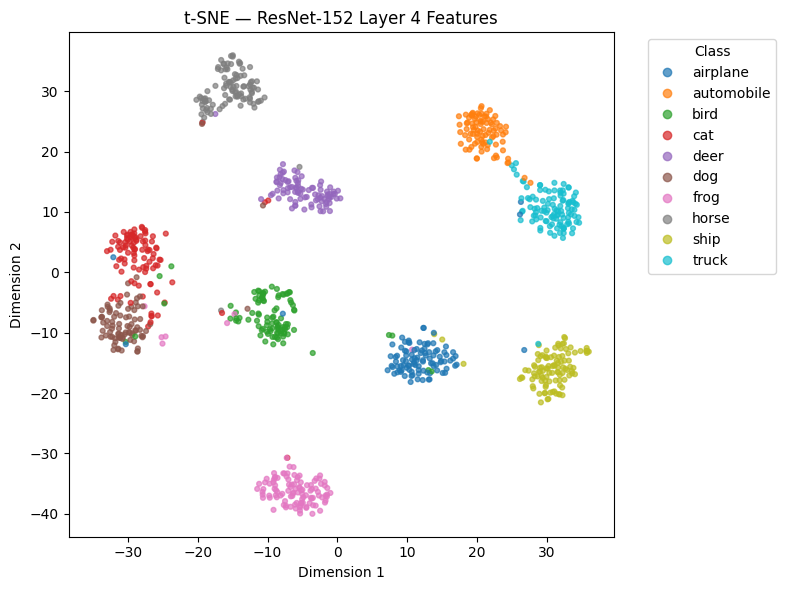

Saved to: task1/results/tsne_vs_umap_tsne.png


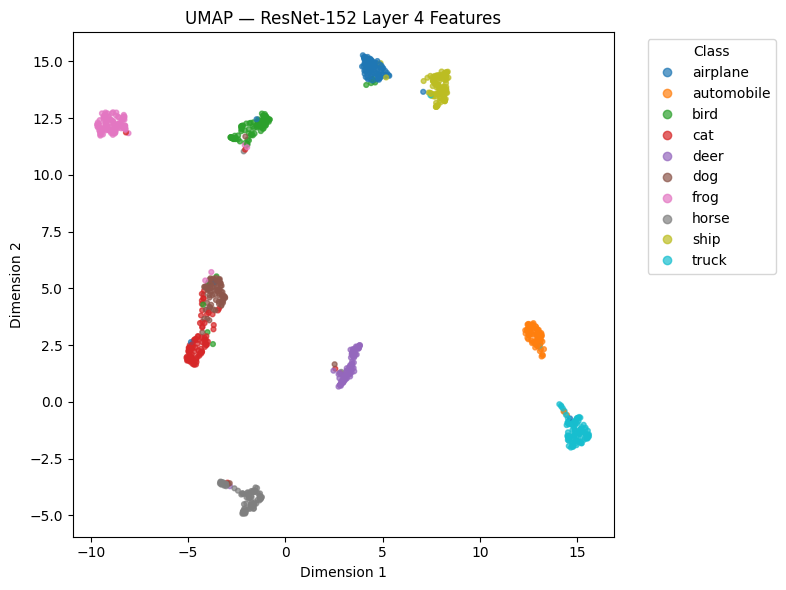

Saved to: task1/results/tsne_vs_umap_umap.png


In [20]:
def plot_embedding(
    embedding,
    labels,
    title,
    save_name,
):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=labels,
        cmap="tab10",
        s=12,
        alpha=0.7,
    )

    handles, _ = scatter.legend_elements()

    plt.legend(
        handles,
        test_dataset.classes,
        title="Class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title(title)

    plt.tight_layout()

    save_path = RESULTS_DIR / save_name

    plt.savefig(
        save_path,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved to:", save_path)


plot_embedding(
    tsne_embedding,
    feature_labels,
    "t-SNE — ResNet-152 Layer 4 Features",
    "tsne_vs_umap_tsne.png",
)

plot_embedding(
    umap_embedding,
    feature_labels,
    "UMAP — ResNet-152 Layer 4 Features",
    "tsne_vs_umap_umap.png",
)

### (b) Feature Similarity Between Confused Classes

#### Predictions and Feature Extraction

In [21]:
class_names = test_dataset.classes

all_predictions = []
all_labels = []
all_features = []


# Unwrap DataParallel for reliable forward-hook feature extraction
if isinstance(pretrained_full_15, nn.DataParallel):
    feature_model_b = pretrained_full_15.module
else:
    feature_model_b = pretrained_full_15

feature_model_b = feature_model_b.to(device)
feature_model_b.eval()


late_features_b = {}


def late_feature_hook_b(model, input, output):
    late_features_b["layer4"] = output.detach().cpu()


hook_b = feature_model_b.layer4.register_forward_hook(
    late_feature_hook_b
)


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = feature_model_b(images)

        predictions = outputs.argmax(dim=1).cpu()

        batch_features = (
            late_features_b["layer4"]
            .mean(dim=(2, 3))
        )

        all_predictions.append(predictions)
        all_labels.append(labels)
        all_features.append(batch_features)


hook_b.remove()


all_predictions = torch.cat(
    all_predictions
).numpy()

all_labels = torch.cat(
    all_labels
).numpy()

all_features = torch.cat(
    all_features
).numpy()


print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)
print("Features:", all_features.shape)

Predictions: (10000,)
Labels: (10000,)
Features: (10000, 2048)


#### Confusion Matrix

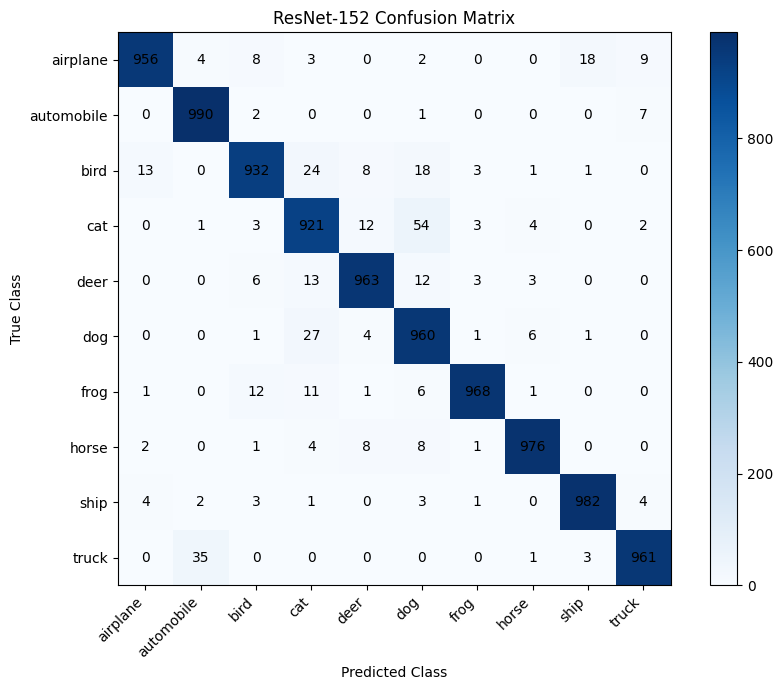

Saved to: task1/results/resnet152_confusion_matrix.png


In [22]:
from sklearn.metrics import confusion_matrix
import numpy as np


conf_matrix = confusion_matrix(
    all_labels,
    all_predictions,
)


plt.figure(figsize=(9, 7))

plt.imshow(
    conf_matrix,
    interpolation="nearest",
    cmap="Blues",
)

plt.title("ResNet-152 Confusion Matrix")
plt.colorbar()


tick_marks = np.arange(
    len(class_names)
)


plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_marks,
    class_names,
)


plt.xlabel("Predicted Class")
plt.ylabel("True Class")


for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center",
        )


plt.tight_layout()


confusion_path = (
    RESULTS_DIR /
    "resnet152_confusion_matrix.png"
)


plt.savefig(
    confusion_path,
    bbox_inches="tight",
)

plt.show()


print("Saved to:", confusion_path)

#### Most Confused Class Pairs

In [23]:
confused_pairs = []


for i in range(len(class_names)):
    for j in range(i + 1, len(class_names)):

        confusion_count = (
            conf_matrix[i, j]
            + conf_matrix[j, i]
        )

        confused_pairs.append(
            (
                class_names[i],
                class_names[j],
                confusion_count,
            )
        )


confused_pairs = sorted(
    confused_pairs,
    key=lambda x: x[2],
    reverse=True,
)


print("Most confused class pairs:")

for class_a, class_b, count in confused_pairs[:5]:
    print(
        f"{class_a} <-> {class_b}: "
        f"{count} confusions"
    )

Most confused class pairs:
cat <-> dog: 81 confusions
automobile <-> truck: 42 confusions
bird <-> cat: 27 confusions
cat <-> deer: 25 confusions
airplane <-> ship: 22 confusions


#### Class Feature Similarity

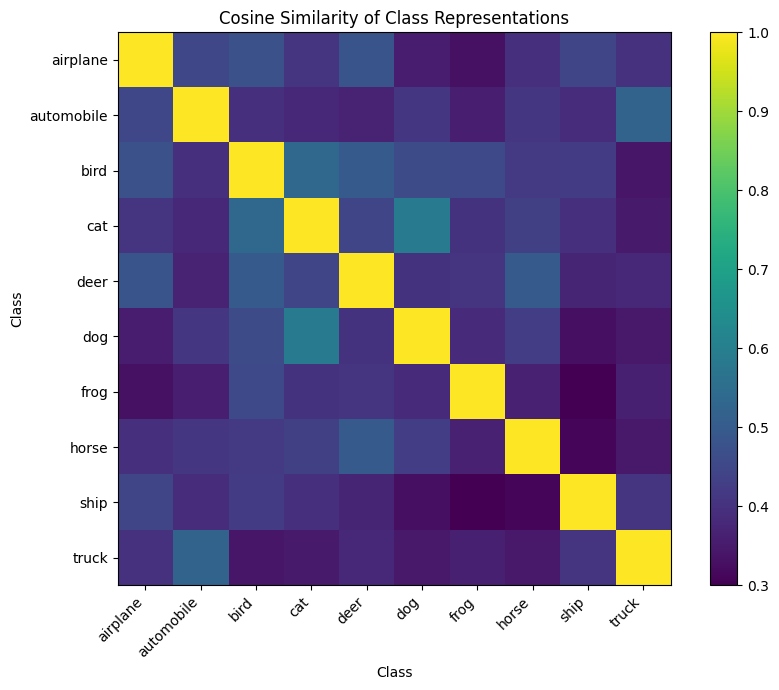

Saved to: task1/results/resnet152_class_feature_similarity.png


In [24]:
from sklearn.metrics.pairwise import cosine_similarity


class_feature_means = []


for class_idx in range(len(class_names)):

    class_features = all_features[
        all_labels == class_idx
    ]

    class_feature_means.append(
        class_features.mean(axis=0)
    )


class_feature_means = np.stack(
    class_feature_means
)


similarity_matrix = cosine_similarity(
    class_feature_means
)


plt.figure(figsize=(9, 7))

plt.imshow(
    similarity_matrix,
    interpolation="nearest",
    cmap="viridis",
)

plt.title(
    "Cosine Similarity of Class Representations"
)

plt.colorbar()


plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_marks,
    class_names,
)


plt.xlabel("Class")
plt.ylabel("Class")

plt.tight_layout()


similarity_path = (
    RESULTS_DIR /
    "resnet152_class_feature_similarity.png"
)


plt.savefig(
    similarity_path,
    bbox_inches="tight",
)

plt.show()


print("Saved to:", similarity_path)

#### Similarity of Most Confused Pairs

In [25]:
print(
    "Feature similarity of most confused pairs:"
)


for class_a, class_b, count in confused_pairs[:5]:

    idx_a = class_names.index(class_a)
    idx_b = class_names.index(class_b)

    similarity = similarity_matrix[
        idx_a,
        idx_b,
    ]

    print(
        f"{class_a} <-> {class_b} | "
        f"Confusions: {count} | "
        f"Cosine similarity: {similarity:.4f}"
    )

Feature similarity of most confused pairs:
cat <-> dog | Confusions: 81 | Cosine similarity: 0.5906
automobile <-> truck | Confusions: 42 | Cosine similarity: 0.5236
bird <-> cat | Confusions: 27 | Cosine similarity: 0.5329
cat <-> deer | Confusions: 25 | Cosine similarity: 0.4462
airplane <-> ship | Confusions: 22 | Cosine similarity: 0.4463


### (c) ResNet-18 vs ResNet-152 Feature Quality

#### ResNet-18 Fine-Tuning

In [27]:
from torchvision.models import resnet18, ResNet18_Weights


resnet18_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

resnet18_model.fc = nn.Linear(
    resnet18_model.fc.in_features,
    10,
)

for param in resnet18_model.parameters():
    param.requires_grad = True

resnet18_model = resnet18_model.to(device)


if torch.cuda.device_count() > 1:
    resnet18_model = nn.DataParallel(
        resnet18_model
    )


criterion_18 = nn.CrossEntropyLoss()

optimizer_18 = torch.optim.Adam(
    resnet18_model.parameters(),
    lr=1e-4,
)

scaler_18 = GradScaler("cuda")


for epoch in range(3):
    train_loss, train_acc = train_one_epoch_amp(
        resnet18_model,
        train_loader,
        criterion_18,
        optimizer_18,
        device,
        scaler_18,
    )

    val_loss, val_acc = evaluate(
        resnet18_model,
        val_loader,
        criterion_18,
        device,
    )

    print(
        f"Epoch {epoch + 1}/3 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


test_loss_18, test_acc_18 = evaluate(
    resnet18_model,
    test_loader,
    criterion_18,
    device,
)

print(f"\nTest Loss: {test_loss_18:.4f}")
print(f"Test Accuracy: {test_acc_18:.4f}")

Epoch 1/3 | Train Loss: 0.3905 | Train Acc: 0.8712 | Val Loss: 0.2081 | Val Acc: 0.9298
Epoch 2/3 | Train Loss: 0.1567 | Train Acc: 0.9490 | Val Loss: 0.2440 | Val Acc: 0.9182
Epoch 3/3 | Train Loss: 0.0941 | Train Acc: 0.9682 | Val Loss: 0.1735 | Val Acc: 0.9416

Test Loss: 0.1995
Test Accuracy: 0.9367


#### Late-Layer Feature Extraction

In [28]:
MAX_COMPARE_SAMPLES = 1000


def extract_layer4_features(model, loader, max_samples):
    # Unwrap DataParallel so forward hooks receive the full batch
    if isinstance(model, nn.DataParallel):
        feature_model = model.module
    else:
        feature_model = model

    feature_model = feature_model.to(device)
    feature_model.eval()

    activations = {}

    def hook_fn(module, input, output):
        activations["layer4"] = output.detach().cpu()

    hook = feature_model.layer4.register_forward_hook(
        hook_fn
    )

    collected_features = []
    collected_labels = []
    samples_collected = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(
                device,
                non_blocking=True,
            )

            _ = feature_model(images)

            remaining = max_samples - samples_collected
            take = min(images.size(0), remaining)

            batch_features = (
                activations["layer4"][:take]
                .mean(dim=(2, 3))
            )

            collected_features.append(batch_features)
            collected_labels.append(labels[:take])

            samples_collected += take

            if samples_collected >= max_samples:
                break

    hook.remove()

    features = torch.cat(
        collected_features
    ).numpy()

    labels = torch.cat(
        collected_labels
    ).numpy()

    return features, labels

In [29]:
resnet152_features, compare_labels = (
    extract_layer4_features(
        pretrained_full_15,
        test_loader,
        MAX_COMPARE_SAMPLES,
    )
)


resnet18_features, compare_labels_18 = (
    extract_layer4_features(
        resnet18_model,
        test_loader,
        MAX_COMPARE_SAMPLES,
    )
)


print(
    "ResNet-152 features:",
    resnet152_features.shape,
)

print(
    "ResNet-18 features:",
    resnet18_features.shape,
)

print(
    "Same labels:",
    np.array_equal(
        compare_labels,
        compare_labels_18,
    ),
)

ResNet-152 features: (1000, 2048)
ResNet-18 features: (1000, 512)
Same labels: True


#### t-SNE Comparison

In [30]:
tsne_152 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
).fit_transform(
    resnet152_features
)


tsne_18 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
).fit_transform(
    resnet18_features
)

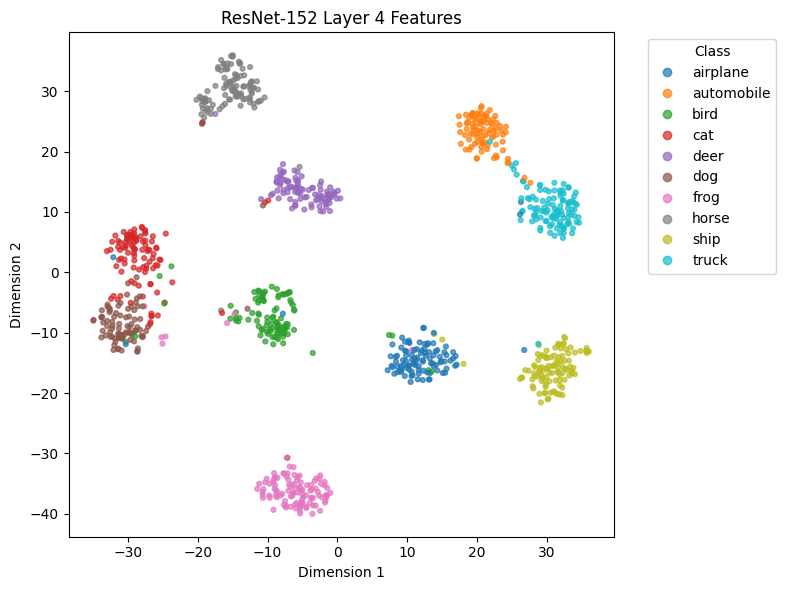

Saved to: task1/results/resnet152_feature_quality.png


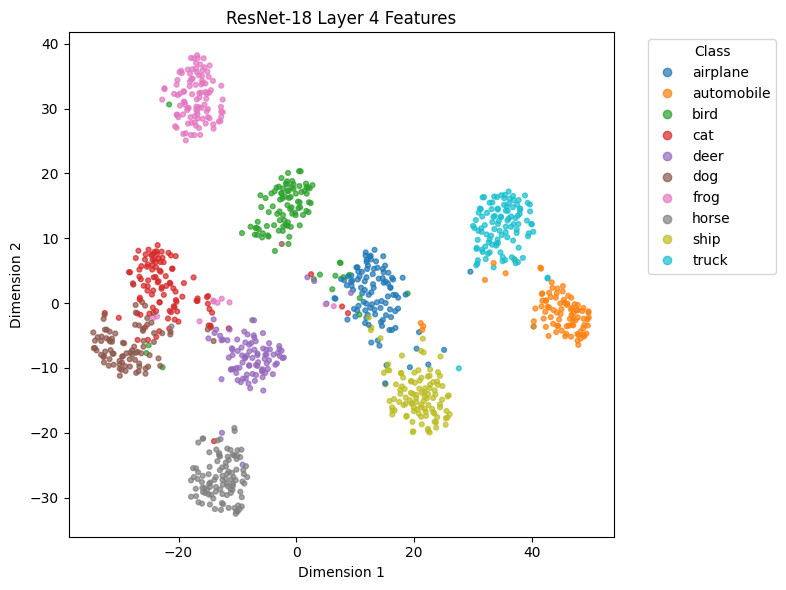

Saved to: task1/results/resnet18_feature_quality.png


In [31]:
plot_embedding(
    tsne_152,
    compare_labels,
    "ResNet-152 Layer 4 Features",
    "resnet152_feature_quality.png",
)


plot_embedding(
    tsne_18,
    compare_labels,
    "ResNet-18 Layer 4 Features",
    "resnet18_feature_quality.png",
)

#### Quantitative Feature Separability

In [32]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


resnet152_scaled = StandardScaler().fit_transform(
    resnet152_features
)

resnet18_scaled = StandardScaler().fit_transform(
    resnet18_features
)


silhouette_152 = silhouette_score(
    resnet152_scaled,
    compare_labels,
)

silhouette_18 = silhouette_score(
    resnet18_scaled,
    compare_labels,
)


print(
    f"ResNet-152 Silhouette Score: "
    f"{silhouette_152:.4f}"
)

print(
    f"ResNet-18 Silhouette Score: "
    f"{silhouette_18:.4f}"
)

ResNet-152 Silhouette Score: 0.2469
ResNet-18 Silhouette Score: 0.2608


#### Comparison Results

In [35]:
feature_quality_results = pd.DataFrame({
    "model": [
        "ResNet-152",
        "ResNet-18",
    ],
    "test_accuracy": [
        test_acc_15,
        test_acc_18,
    ],
    "silhouette_score": [
        silhouette_152,
        silhouette_18,
    ],
})


feature_quality_path = (
    RESULTS_DIR /
    "resnet18_vs_resnet152.csv"
)

feature_quality_results.to_csv(
    feature_quality_path,
    index=False,
)


print(feature_quality_results)
print("\nSaved to:", feature_quality_path)

        model  test_accuracy  silhouette_score
0  ResNet-152         0.9609          0.246937
1   ResNet-18         0.9367          0.260805

Saved to: task1/results/resnet18_vs_resnet152.csv
